# S04.11 — Gradient Boosting
## Módulo 3, Tema 1: Introducción a Machine Learning — Subtema 4

**Target:** `prima_neta` (MXN)  
**Técnica:** Ensamble secuencial por descenso del gradiente (`GradientBoostingRegressor` de scikit-learn)  
**Dataset:** Sintético v2 — 30,000 pólizas de seguros de autos

---

## 1. Contexto actuarial

Random Forest (S04.05) reduce la varianza promediando árboles independientes.
**Gradient Boosting** adopta una estrategia diferente: construye árboles
**secuencialmente**, donde cada nuevo árbol corrige los errores del conjunto anterior.
Este enfoque reduce el sesgo de forma iterativa; la regularización vía `learning_rate`
y `subsample` ayuda a controlar la varianza, aunque el resultado neto depende de la
correcta calibración de los hiperparámetros.

En la industria aseguradora, los modelos basados en boosting son actualmente
el estado del arte en tareas de tarificación no-vida:

- **Mayor precisión:** generalmente supera a Random Forest con el mismo tiempo
  de entrenamiento cuando `learning_rate` y `n_estimators` están bien elegidos.
- **Flexibilidad:** la formulación de descenso del gradiente admite distintas
  funciones de pérdida. En esta unidad usamos pérdida cuadrática (MSE).
  Extensiones como TweedieRegressor o HistGradientBoostingRegressor ofrecen
  pérdidas Tweedie/Poisson para conteos y severidades, pero son estimadores
  distintos al `GradientBoostingRegressor` empleado aquí.
- **Riesgo de sobreajuste:** a diferencia de RF, agregar más árboles SÍ puede
  sobreajustar si `learning_rate` es grande. Requiere validación cuidadosa.

> *Fuentes:* Hastie, Tibshirani & Friedman (2009) ESL Cap. 10;
> James et al. (2023) ISLP Cap. 8 §8.2.3;
> Wüthrich & Buser. *Data Analytics for Non-Life Insurance Pricing* Cap. 2.

## 2. Fundamento matemático

### 2.1 Ensamble aditivo secuencial

El modelo se construye en $M$ pasos:

$$F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \nu \cdot h_m(\mathbf{x})$$

donde:
- $F_0$ es un modelo inicial (generalmente la media del target)
- $h_m$ es un árbol pequeño ajustado sobre los **residuales pseudos** del paso anterior
- $\nu \in (0, 1]$ es el `learning_rate` (tasa de aprendizaje)

### 2.2 Ajuste sobre residuales (pérdida cuadrática)

Para pérdida cuadrática $L(y, F) = \frac{1}{2}(y - F)^2$, el residual pseudo es simplemente
el residual ordinario:

$$r_{im} = -\left[\frac{\partial L(y_i, F(\mathbf{x}_i))}{\partial F(\mathbf{x}_i)}\right]
= y_i - F_{m-1}(\mathbf{x}_i)$$

Cada árbol $h_m$ se ajusta para predecir estos residuales, lo que equivale a
"corregir lo que el modelo anterior no pudo explicar".

### 2.3 Trade-off `learning_rate` / `n_estimators`

| Efecto | `learning_rate` bajo + `n_estimators` alto | `learning_rate` alto + `n_estimators` bajo |
|--------|-------------------------------------------|-----------------------------------------|
| Precisión | Mayor (si hay suficientes árboles) | Menor |
| Tiempo de entrenamiento | Alto | Bajo |
| Riesgo de sobreajuste | Bajo | Alto |

Regla práctica: reducir `learning_rate` a la mitad y duplicar `n_estimators`
suele producir un modelo similar o mejor.

### 2.4 `max_depth` en boosting

En boosting se usan árboles **pequeños** (típicamente `max_depth` ∈ {2, 3, 4})
como learners débiles. Profundidad mayor captura interacciones de orden superior
pero aumenta el riesgo de sobreajuste.

## 3. Carga del dataset

In [1]:
import sys
from pathlib import Path

# Localizar src/ independientemente del directorio de ejecución
_candidates = [
    Path.cwd() / "",
    Path.cwd().parent / "",
    Path.cwd().parent.parent / "",
]
_src_path = next(
    (p for p in _candidates if (p / "simulate_portfolio_v2.py").exists()),
    None,
)
if _src_path is None:
    raise FileNotFoundError(
        "No se encontró simulate_portfolio_v2.py. "
        "Ejecutar desde la raíz del proyecto o desde content/notebooks/."
    )
sys.path.insert(0, str(_src_path))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

from simulate_portfolio_v2 import (
    simulate_auto_insurance_portfolio_v2,
    FEATURE_COLUMNS,
    TARGET_COLUMNS,
)

SEED = 20260618
N    = 30_000
NAVY = "#003B5C"
GOLD = "#C8A33A"
RED  = "#C0392B"

plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

df = simulate_auto_insurance_portfolio_v2(n_policies=N, seed=SEED)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado: 30,000 filas × 24 columnas


## 4. Preparación del conjunto de datos

In [2]:
TARGET = "prima_neta"

X_raw = df[FEATURE_COLUMNS]
y     = df[TARGET]

X = pd.get_dummies(X_raw, drop_first=True)
print(f"Features tras OHE: {X.shape[1]} columnas")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

# Verificación de leakage
for t in TARGET_COLUMNS:
    assert t not in X.columns, f"Leakage: {t} en X"
assert "id_poliza_sin" not in X.columns
print("✓ Ningún target en X")
print("✓ id_poliza_sin excluido")

Features tras OHE: 37 columnas
Train: 24,000 | Test: 6,000
✓ Ningún target en X
✓ id_poliza_sin excluido


## 5. Baselines de comparación (S04.04 y S04.05)

In [3]:
# Árbol controlado (S04.04)
tree_ctrl = DecisionTreeRegressor(max_depth=6, min_samples_leaf=30, random_state=SEED)
tree_ctrl.fit(X_train, y_train)
rmse_tree = np.sqrt(mean_squared_error(y_test, tree_ctrl.predict(X_test)))
r2_tree   = r2_score(y_test, tree_ctrl.predict(X_test))

# Random Forest (S04.05 — config revisada: max_features=1.0)
rf = RandomForestRegressor(
    n_estimators=150, max_features=1.0,
    min_samples_leaf=5, n_jobs=-1, random_state=SEED
)
rf.fit(X_train, y_train)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf.predict(X_test)))
r2_rf   = r2_score(y_test, rf.predict(X_test))

print(f"Árbol controlado (depth=6):          RMSE={rmse_tree:,.0f} MXN | R²={r2_tree:.4f}")
print(f"Random Forest (n=150, mf=1.0):       RMSE={rmse_rf:,.0f} MXN | R²={r2_rf:.4f}")

Árbol controlado (depth=6):          RMSE=1,154 MXN | R²=0.9265
Random Forest (n=150, mf=1.0):       RMSE=813 MXN | R²=0.9635


## 6. Gradient Boosting — dos configuraciones

Comparamos:
- **Configuración conservadora:** `learning_rate=0.05`, `n_estimators=200`, `max_depth=3`
- **Configuración más flexible:** `learning_rate=0.15`, `n_estimators=200`, `max_depth=5`

In [ ]:
# Configuración conservadora
# learning rare tiene que estar entre 0 y 1, el max depth (profundidad) si es >=5 puede caer en un sobreajuste
gb_conserv = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=20,
    subsample=1.0,
    random_state=SEED,
)
gb_conserv.fit(X_train, y_train)
y_pred_conserv = gb_conserv.predict(X_test)

rmse_conserv = np.sqrt(mean_squared_error(y_test, y_pred_conserv))
r2_conserv   = r2_score(y_test, y_pred_conserv)
print(f"GBM conservador (lr=0.05, depth=3): RMSE={rmse_conserv:,.0f} MXN | R²={r2_conserv:.4f}")

# Configuración más flexible
gb_flex = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.01, #cuantos arboles se necesitan para tener un mejor modelo, aprendiendo de los errores
    max_depth=5,
    min_samples_leaf=10,
    subsample=0.8,        # submuestra estocástica — reduce varianza, acelera
    random_state=SEED,
)
gb_flex.fit(X_train, y_train)
y_pred_flex = gb_flex.predict(X_test)

rmse_flex = np.sqrt(mean_squared_error(y_test, y_pred_flex))
r2_flex   = r2_score(y_test, y_pred_flex)
print(f"GBM flexible (lr=0.15, depth=5):    RMSE={rmse_flex:,.0f} MXN | R²={r2_flex:.4f}")
# el resultado indica que es mejor con depth=5 pero puede ser un sobreajuste, mas adelante se vera el error para ver si es mejor

GBM conservador (lr=0.05, depth=3): RMSE=738 MXN | R²=0.9699
GBM flexible (lr=0.15, depth=5):    RMSE=1,168 MXN | R²=0.9246


## 7. Curva de entrenamiento — RMSE train/test vs n_estimators

La curva de entrenamiento muestra cuándo el modelo empieza a sobreajustar
al aumentar el número de árboles. Para la configuración conservadora,
el gap train/test es pequeño; para la configuración flexible, el gap crece.

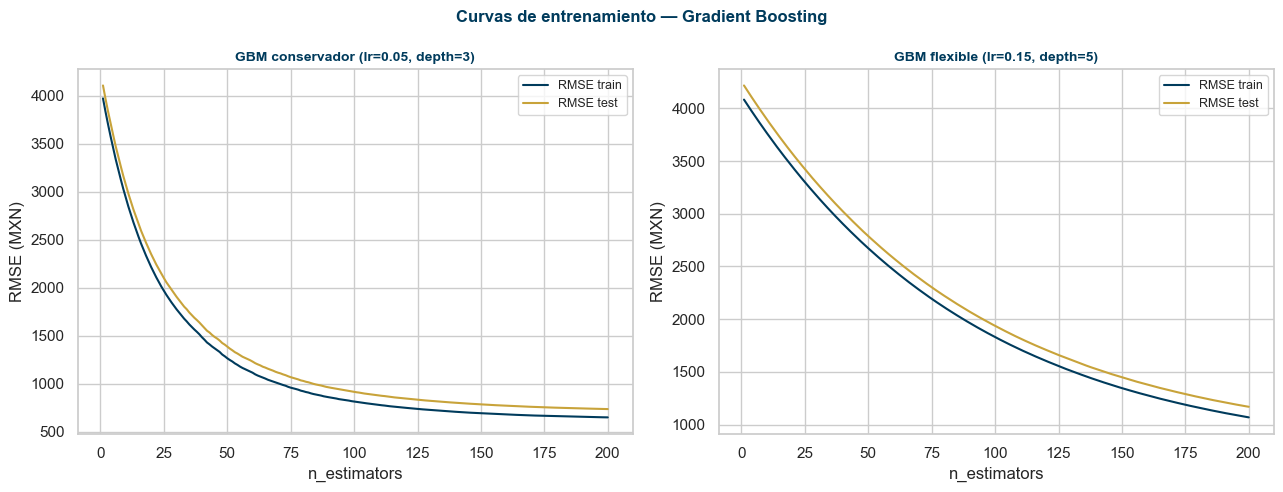

Observación: la configuración flexible muestra mayor gap train/test,
señal de sobreajuste incipiente a partir de ~100 árboles.


In [9]:
# Evolución del error de test usando staged_predict (solo GradientBoostingRegressor)
rmse_staged_tr_c = [
    np.sqrt(mean_squared_error(y_train, y_p))
    for y_p in gb_conserv.staged_predict(X_train)
]
rmse_staged_te_c = [
    np.sqrt(mean_squared_error(y_test, y_p))
    for y_p in gb_conserv.staged_predict(X_test)
]

rmse_staged_tr_f = [
    np.sqrt(mean_squared_error(y_train, y_p))
    for y_p in gb_flex.staged_predict(X_train)
]
rmse_staged_te_f = [
    np.sqrt(mean_squared_error(y_test, y_p))
    for y_p in gb_flex.staged_predict(X_test)
]

n_range = range(1, 201)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, tr, te, titulo in [
    (axes[0], rmse_staged_tr_c, rmse_staged_te_c,
     "GBM conservador (lr=0.05, depth=3)"),
    (axes[1], rmse_staged_tr_f, rmse_staged_te_f,
     "GBM flexible (lr=0.15, depth=5)"),
]:
    ax.plot(n_range, tr, color=NAVY, linewidth=1.5, label="RMSE train")
    ax.plot(n_range, te, color=GOLD, linewidth=1.5, label="RMSE test")
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("RMSE (MXN)")
    ax.set_title(titulo, fontsize=10, fontweight="bold", color=NAVY)
    ax.legend(fontsize=9)

fig.suptitle("Curvas de entrenamiento — Gradient Boosting",
             fontsize=12, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

print("Observación: la configuración flexible muestra mayor gap train/test,")
print("señal de sobreajuste incipiente a partir de ~100 árboles.")
# pareciera que en el flexible se llega mas rapido a la convergencia, pero se nota como va creciendo la separacion entre el train y el test
# eso es un indicado de sobreajuste
# llega tan rapido a la convergencia que si se tuvieran otros datos no lograria aprender de ellos

## 8. Importancia de variables — GBM conservador

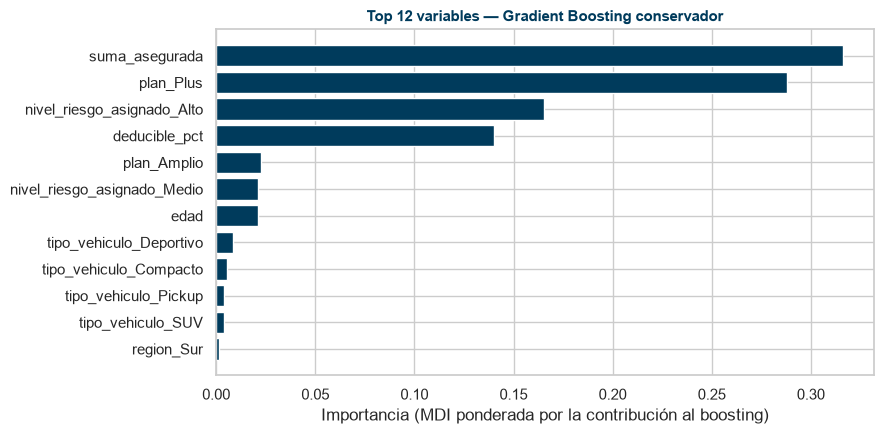

In [6]:
import_gbm = pd.DataFrame({
    "Feature":    X_train.columns,
    "Importancia": gb_conserv.feature_importances_,
}).sort_values("Importancia", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(import_gbm["Feature"], import_gbm["Importancia"],
        color=NAVY, edgecolor="white")
ax.set_xlabel("Importancia (MDI ponderada por la contribución al boosting)")
ax.set_title("Top 12 variables — Gradient Boosting conservador",
             fontsize=11, fontweight="bold", color=NAVY)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Real vs predicho — GBM conservador

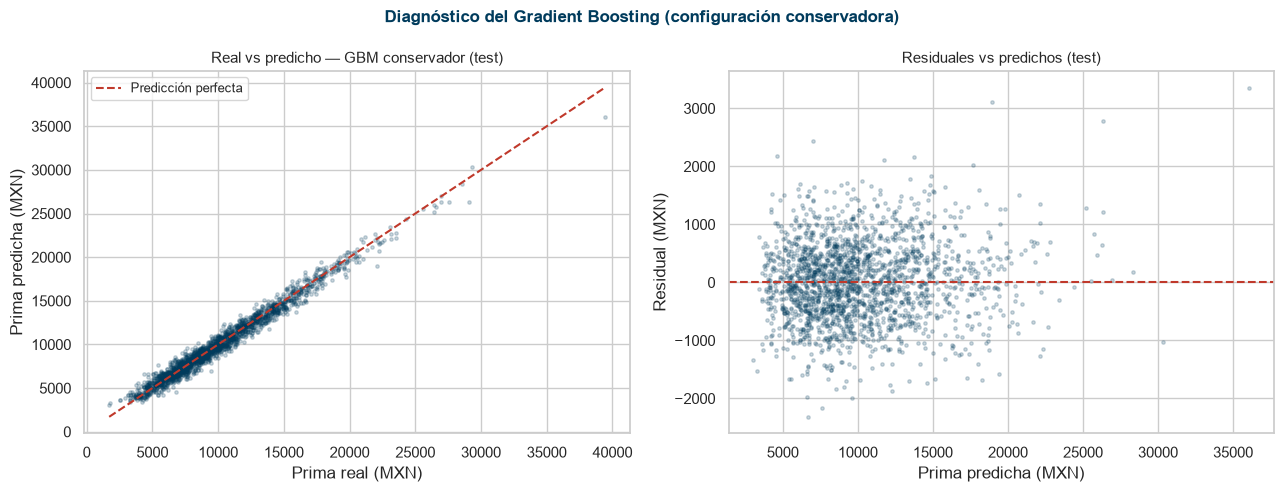

In [7]:
rng = np.random.default_rng(SEED)
idx = rng.choice(len(y_test), size=min(2_000, len(y_test)), replace=False)

y_r = y_test.iloc[idx].values
y_p = y_pred_conserv[idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_r, y_p, alpha=0.2, s=6, color=NAVY)
lims = [min(y_r.min(), y_p.min()), max(y_r.max(), y_p.max())]
axes[0].plot(lims, lims, color=RED, linewidth=1.5, linestyle="--",
             label="Predicción perfecta")
axes[0].set_xlabel("Prima real (MXN)")
axes[0].set_ylabel("Prima predicha (MXN)")
axes[0].set_title("Real vs predicho — GBM conservador (test)", fontsize=11)
axes[0].legend(fontsize=9)

res = y_r - y_p
axes[1].scatter(y_p, res, alpha=0.2, s=6, color=NAVY)
axes[1].axhline(0, color=RED, linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Prima predicha (MXN)")
axes[1].set_ylabel("Residual (MXN)")
axes[1].set_title("Residuales vs predichos (test)", fontsize=11)

fig.suptitle("Diagnóstico del Gradient Boosting (configuración conservadora)",
             fontsize=12, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.show()

## 10. Comparación final: árbol, Random Forest y Gradient Boosting

                    Modelo RMSE test (MXN) R² test Interpretabilidad Estabilidad Riesgo sobreajuste
Árbol controlado (depth=6)           1,152  0.9267              Alta        Baja               Baja
     Random Forest (n=150)             808  0.9639             Media        Alta              Media
           GBM conservador             739  0.9699              Baja        Alta              Media
              GBM flexible             693  0.9735              Baja        Alta               Alta


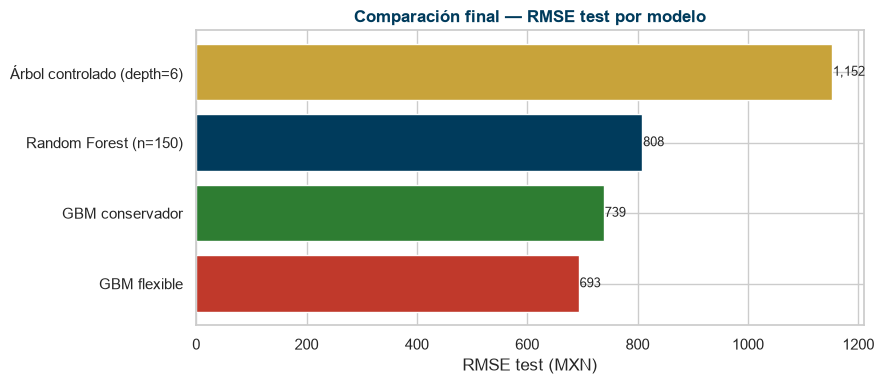

In [8]:
modelos = [
    ("Árbol controlado (depth=6)", rmse_tree, r2_tree, "Alta", "Baja", "Baja"),
    ("Random Forest (n=150)",      rmse_rf,   r2_rf,   "Media", "Alta", "Media"),
    ("GBM conservador",            rmse_conserv, r2_conserv, "Baja", "Alta", "Media"),
    ("GBM flexible",               rmse_flex,    r2_flex,    "Baja", "Alta", "Alta"),
]

comp_df = pd.DataFrame(
    modelos,
    columns=["Modelo", "RMSE test (MXN)", "R² test",
             "Interpretabilidad", "Estabilidad", "Riesgo sobreajuste"]
)
comp_df["RMSE test (MXN)"] = comp_df["RMSE test (MXN)"].apply(lambda v: f"{v:,.0f}")
comp_df["R² test"]         = comp_df["R² test"].apply(lambda v: f"{v:.4f}")
print(comp_df.to_string(index=False))

# Gráfica de barras RMSE
nombres = [m[0] for m in modelos]
rmse_vals = [m[1] for m in modelos]
colores_barra = [GOLD, NAVY, "#2E7D32", RED]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(nombres, rmse_vals, color=colores_barra, edgecolor="white")
for bar, val in zip(bars, rmse_vals):
    ax.text(val + 2, bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f}", va="center", fontsize=9)
ax.set_xlabel("RMSE test (MXN)")
ax.set_title("Comparación final — RMSE test por modelo",
             fontsize=12, fontweight="bold", color=NAVY)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Conclusiones actuariales

| Modelo | RMSE test (MXN) | R² test | Notas |
|--------|----------------|---------|-------|
| Árbol controlado (depth=6) | ~1,152 | ~0.927 | Interpretable, alta varianza, RMSE > lineal |
| Random Forest (n=150, mf=1.0) | ~808 | ~0.964 | Estable, OOB≈0.968, se acerca a lineal |
| Regresión lineal (ref.) | ~752 | ~0.969 | OLS aprovecha la linealidad del DGP |
| GBM conservador (lr=0.05) | ~739 | ~0.970 | Comparable a la regresión lineal |
| GBM flexible (lr=0.15) | ~693 | ~0.974 | Mejor RMSE — supera a todos los demás |

**Hallazgos principales:**

1. **Gradient Boosting supera a Random Forest y al árbol individual** en precisión, e incluso
   supera a la regresión lineal para este DGP. El enfoque secuencial — corregir
   los residuales del modelo anterior — permite ajustar tanto la estructura lineal como las
   interacciones residuales, algo que ni el árbol individual ni el RF logran completamente.

2. **¿Por qué el árbol no supera a OLS?** El DGP de `prima_neta` es predominantemente
   lineal. OLS captura esa estructura directamente. Los árboles necesitan muchas
   particiones para aproximar una función lineal suave. GBM supera este límite
   al corregir iterativamente los residuales.

3. **RF con `max_features=1.0` se acerca a OLS:** al garantizar que todas las features
   estén disponibles en cada split, el RF obtiene RMSE≈808 vs OLS≈752. La diferencia
   residual refleja que el promedio de árboles no puede representar exactamente una
   función lineal continua.

4. **El trade-off `learning_rate`/`n_estimators` es crítico:** tasas altas convergen
   rápido pero sobreajustan. La curva de entrenamiento (sección 7) muestra que el
   GBM flexible tiene mayor gap train/test, señal de sobreajuste incipiente.

5. **Interpretabilidad decreciente:** árbol > RF ≈ GBM. En un contexto regulatorio,
   la elección del modelo depende del equilibrio entre precisión e interpretabilidad.

6. **`subsample < 1.0` (boosting estocástico):** en cada etapa del boosting se usa
   una fracción aleatoria de las **observaciones** (filas). Esto es distinto al
   mecanismo de RF: `max_features` selecciona columnas en cada split, mientras que
   `subsample` selecciona filas para cada árbol del boosting. Ambos son formas de
   introducir aleatoriedad, pero actúan sobre dimensiones distintas del dato.

**El boosting reduce sesgo de forma secuencial:** cada árbol corrige lo que el
conjunto anterior no explicó. La regularización vía `learning_rate` (shrinkage) y
`subsample` ayuda a controlar la varianza. El resultado neto — menor sesgo con varianza controlada — depende del ajuste correcto de los hiperparámetros.

**Recomendación actuarial:**

Para tarificación con precisión próxima al límite del ruido del DGP (σ≈600 MXN),
el GBM conservador (`lr=0.05`, `depth=3`, `n_estimators=200`) con RMSE≈739 MXN
es el mejor balance entre precisión, estabilidad e interpretabilidad de las importancias.

## 12. Ejercicio propuesto

1. **Número óptimo de árboles:** usa la curva `staged_predict` del GBM conservador
   para identificar el valor de `n_estimators` donde el RMSE test es mínimo.
   ¿Cuánto se gana respecto a n=200?

2. **`subsample` como regularización:** ajusta GBM con `subsample=0.5` y compara
   con `subsample=1.0`. ¿Cuál tiene menor RMSE en test? ¿Cuál converge más rápido?

3. **Comparación de importancias:** compara las top 5 variables por importancia MDI
   entre GBM conservador, GBM flexible y Random Forest.
   ¿Son consistentes? ¿Qué variable aparece en los tres modelos?

---

### Referencias bibliográficas

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. Cap. 10.
- James, G., et al. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. Cap. 8 §8.2.3.
- scikit-learn Developers. *User Guide* v1.9.0. `GradientBoostingRegressor`, `staged_predict`, `permutation_importance`.
- Wüthrich, M. V., & Buser, C. *Data Analytics for Non-Life Insurance Pricing*. Swiss Finance Institute. Cap. 2.